In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

In [2]:
import pandas as pd
import os

In [3]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
import os

print("Dataset path:")
print(path)

print("\nFiles and folders:")
print(os.listdir(path))

Dataset path:
/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8

Files and folders:
['validation', 'train', 'test']


In [5]:
#Understand the folder structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '    ' * level

    print(indent + os.path.basename(root) + '/')

    if level >= 2:
        dirs[:] = []

8/
    validation/
        watermelon/
        pineapple/
        pear/
        sweetcorn/
        cauliflower/
        turnip/
        garlic/
        tomato/
        soy beans/
        spinach/
        paprika/
        orange/
        lettuce/
        eggplant/
        onion/
        grapes/
        sweetpotato/
        beetroot/
        carrot/
        corn/
        jalepeno/
        raddish/
        capsicum/
        cabbage/
        potato/
        ginger/
        peas/
        mango/
        pomegranate/
        chilli pepper/
        apple/
        lemon/
        banana/
        cucumber/
        kiwi/
        bell pepper/
    train/
        watermelon/
        pineapple/
        pear/
        sweetcorn/
        cauliflower/
        turnip/
        garlic/
        tomato/
        soy beans/
        spinach/
        paprika/
        orange/
        lettuce/
        eggplant/
        onion/
        grapes/
        sweetpotato/
        beetroot/
        carrot/
        corn/
      

## 3. Exploring the Dataset

In [6]:
#Check How Many Images We Have

train_path = os.path.join(path, "train")
validation_path = os.path.join(path, "validation")
test_path = os.path.join(path, "test")

print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)

Train path: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/train
Validation path: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/validation
Test path: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/test


In [8]:
#Count Images in Each Dataset
def count_images(folder_path):
    total = 0

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                total += 1

    return total


train_count = count_images(train_path)
validation_count = count_images(validation_path)
test_count = count_images(test_path)

print("Training images:", train_count)
print("Validation images:", validation_count)
print("Test images:", test_count)
print("Total images:", train_count + validation_count + test_count)

Training images: 3115
Validation images: 351
Test images: 359
Total images: 3825


In [9]:
#Count Images for Each Class
classes = sorted(os.listdir(train_path))

print("Number of classes:", len(classes))
print("\nClasses:")

for i, class_name in enumerate(classes, start=1):
    print(i, ":", class_name)

Number of classes: 36

Classes:
1 : apple
2 : banana
3 : beetroot
4 : bell pepper
5 : cabbage
6 : capsicum
7 : carrot
8 : cauliflower
9 : chilli pepper
10 : corn
11 : cucumber
12 : eggplant
13 : garlic
14 : ginger
15 : grapes
16 : jalepeno
17 : kiwi
18 : lemon
19 : lettuce
20 : mango
21 : onion
22 : orange
23 : paprika
24 : pear
25 : peas
26 : pineapple
27 : pomegranate
28 : potato
29 : raddish
30 : soy beans
31 : spinach
32 : sweetcorn
33 : sweetpotato
34 : tomato
35 : turnip
36 : watermelon


In [10]:
#Count Each Class
class_counts = {}

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    class_counts[class_name] = count


class_counts

{'apple': 68,
 'banana': 75,
 'beetroot': 88,
 'bell pepper': 90,
 'cabbage': 92,
 'capsicum': 89,
 'carrot': 82,
 'cauliflower': 79,
 'chilli pepper': 87,
 'corn': 87,
 'cucumber': 94,
 'eggplant': 84,
 'garlic': 92,
 'ginger': 68,
 'grapes': 100,
 'jalepeno': 88,
 'kiwi': 88,
 'lemon': 82,
 'lettuce': 97,
 'mango': 86,
 'onion': 94,
 'orange': 69,
 'paprika': 83,
 'pear': 89,
 'peas': 100,
 'pineapple': 99,
 'pomegranate': 79,
 'potato': 77,
 'raddish': 81,
 'soy beans': 97,
 'spinach': 97,
 'sweetcorn': 91,
 'sweetpotato': 69,
 'tomato': 92,
 'turnip': 98,
 'watermelon': 84}

In [11]:
import pandas as pd

class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

class_distribution

,Class,Image_Count
0,apple,68
1,banana,75
2,beetroot,88
3,bell pepper,90
4,cabbage,92
5,capsicum,89
6,carrot,82
7,cauliflower,79
8,chilli pepper,87
9,corn,87


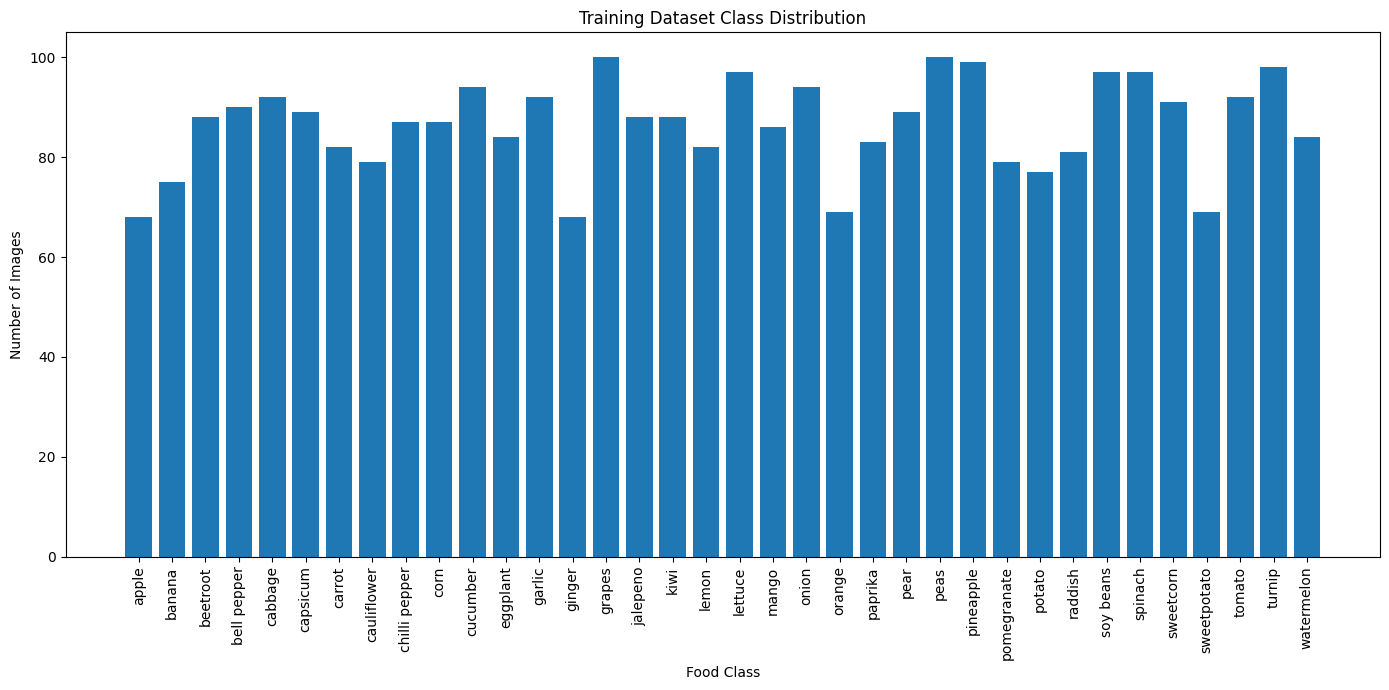

In [13]:
#Visualize Class Distribution
plt.figure(figsize=(14, 7))

plt.bar(
    class_distribution["Class"],
    class_distribution["Image_Count"]
)

plt.xticks(rotation=90)

plt.xlabel("Food Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.tight_layout()
plt.show()

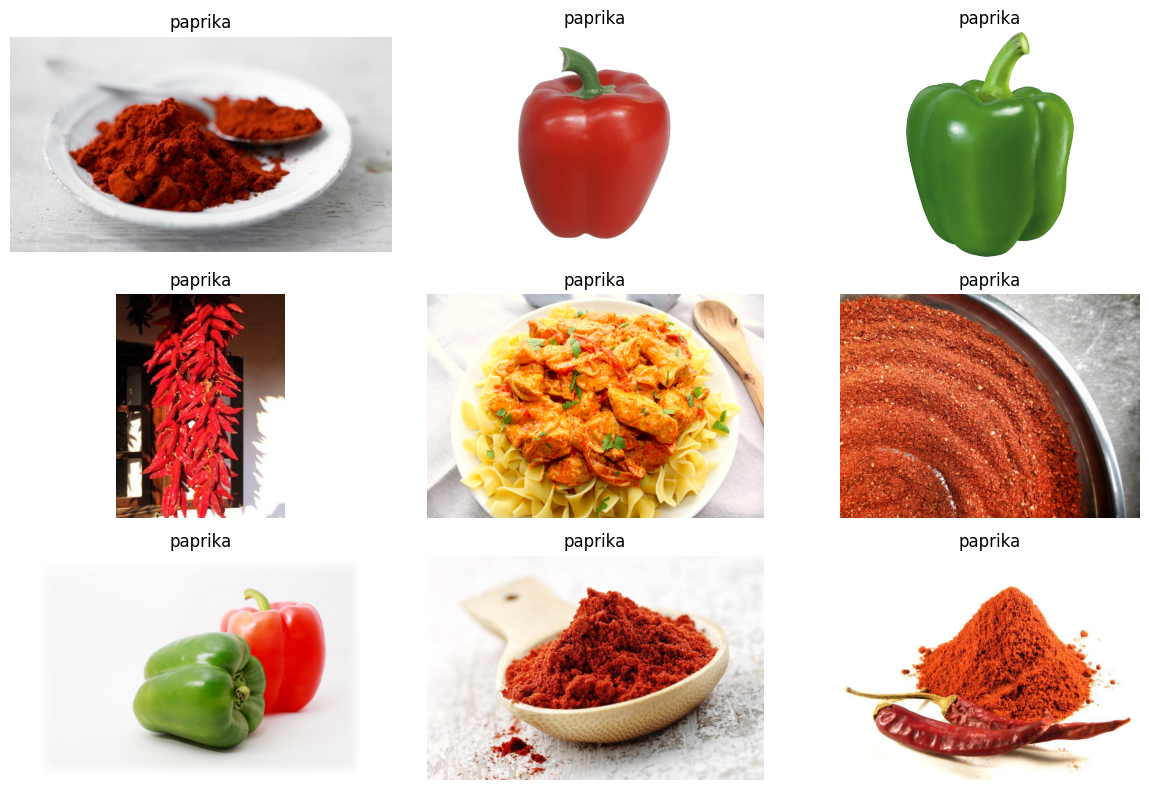

In [14]:
#Display Some Images
from PIL import Image
import random

random_class = random.choice(classes)

class_folder = os.path.join(train_path, random_class)

image_files = [
    file for file in os.listdir(class_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

plt.figure(figsize=(12, 8))

for i in range(9):

    image_file = random.choice(image_files)
    image_path = os.path.join(class_folder, image_file)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(random_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

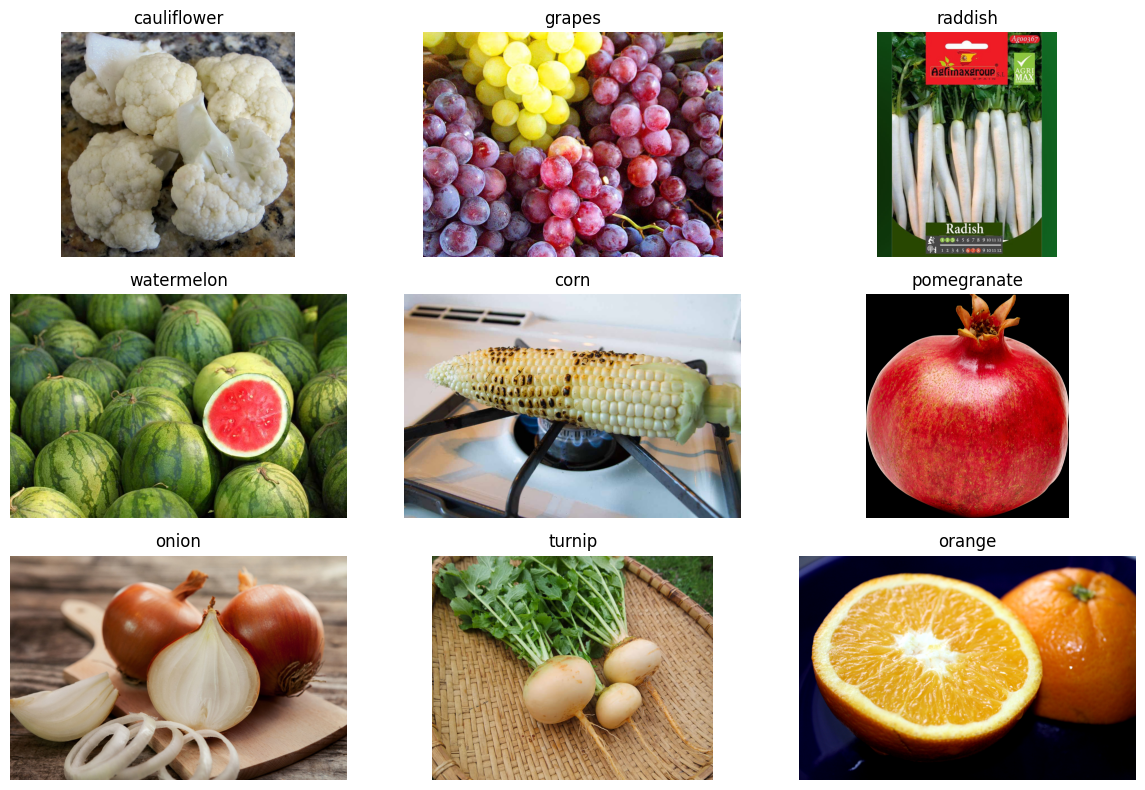

In [15]:
#Show Different Classes
selected_classes = random.sample(classes, 9)

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(selected_classes):

    class_folder = os.path.join(train_path, class_name)

    image_files = [
        file for file in os.listdir(class_folder)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(image_files)
    image_path = os.path.join(class_folder, image_file)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Create Our 2 Categories

In [16]:
fruit_classes = [
    "apple",
    "banana",
    "grapes",
    "kiwi",
    "lemon",
    "mango",
    "orange",
    "pear",
    "pineapple",
    "pomegranate",
    "watermelon"
]

In [17]:
vegetable_classes = [
    "bell pepper",
    "beetroot",
    "cabbage",
    "capsicum",
    "carrot",
    "cauliflower",
    "chilli pepper",
    "corn",
    "cucumber",
    "eggplant",
    "garlic",
    "ginger",
    "jalepeno",
    "lettuce",
    "onion",
    "paprika",
    "peas",
    "potato",
    "raddish",
    "soy beans",
    "spinach",
    "sweetcorn",
    "sweetpotato",
    "tomato",
    "turnip"
]

In [18]:
#Verify Every Class Is Included
all_classes = set(classes)

mapped_classes = set(fruit_classes + vegetable_classes)

print("Dataset classes:", len(all_classes))
print("Mapped classes:", len(mapped_classes))

print("\nClasses not mapped:")

print(all_classes - mapped_classes)

print("\nClasses mapped but not in dataset:")

print(mapped_classes - all_classes)

Dataset classes: 36
Mapped classes: 36

Classes not mapped:
set()

Classes mapped but not in dataset:
set()


In [19]:
print("Training images:", train_count)
print("Validation images:", validation_count)
print("Test images:", test_count)
print("Number of classes:", len(classes))
print(all_classes - mapped_classes)

Training images: 3115
Validation images: 351
Test images: 359
Number of classes: 36
set()


##  Preparing the Dataset for Binary Classification

In [20]:
#Create folders
import os

binary_path = "/content/binary_dataset"

for split in ["train", "validation", "test"]:

    os.makedirs(
        os.path.join(binary_path, split, "Fruits"),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(binary_path, split, "Vegetables"),
        exist_ok=True
    )

print("Binary dataset folders created successfully!")

Binary dataset folders created successfully!


In [21]:
# Copy Images
import shutil

def create_binary_dataset(source_path, destination_path):

    for class_name in os.listdir(source_path):

        class_path = os.path.join(source_path, class_name)

        if not os.path.isdir(class_path):
            continue

        # Decide whether this class is a fruit or vegetable
        if class_name in fruit_classes:
            category = "Fruits"

        elif class_name in vegetable_classes:
            category = "Vegetables"

        else:
            continue

        destination_category = os.path.join(
            destination_path,
            category
        )

        # Copy images
        for file_name in os.listdir(class_path):

            if file_name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                source_file = os.path.join(
                    class_path,
                    file_name
                )

                destination_file = os.path.join(
                    destination_category,
                    f"{class_name}_{file_name}"
                )

                shutil.copy2(
                    source_file,
                    destination_file
                )

In [22]:
create_binary_dataset(
    train_path,
    os.path.join(binary_path, "train")
)

create_binary_dataset(
    validation_path,
    os.path.join(binary_path, "validation")
)

create_binary_dataset(
    test_path,
    os.path.join(binary_path, "test")
)

print("Images successfully organized into Fruits and Vegetables!")

Images successfully organized into Fruits and Vegetables!


In [23]:
#Verify New Dataset
for split in ["train", "validation", "test"]:

    fruits_path = os.path.join(
        binary_path,
        split,
        "Fruits"
    )

    vegetables_path = os.path.join(
        binary_path,
        split,
        "Vegetables"
    )

    fruits_count = len(os.listdir(fruits_path))
    vegetables_count = len(os.listdir(vegetables_path))

    print("\n", split.upper())
    print("Fruits:", fruits_count)
    print("Vegetables:", vegetables_count)
    print("Total:", fruits_count + vegetables_count)


 TRAIN
Fruits: 919
Vegetables: 2196
Total: 3115

 VALIDATION
Fruits: 107
Vegetables: 244
Total: 351

 TEST
Fruits: 109
Vegetables: 250
Total: 359


##  Loading Images for Model Training

In [24]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [25]:
#Load Training Dataset
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(binary_path, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

Found 3115 files belonging to 2 classes.


In [26]:
#Load Validation Dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(binary_path, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 351 files belonging to 2 classes.


In [27]:
#Load Test Dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(binary_path, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 359 files belonging to 2 classes.


In [28]:
print("Classes:", train_dataset.class_names)

Classes: ['Fruits', 'Vegetables']


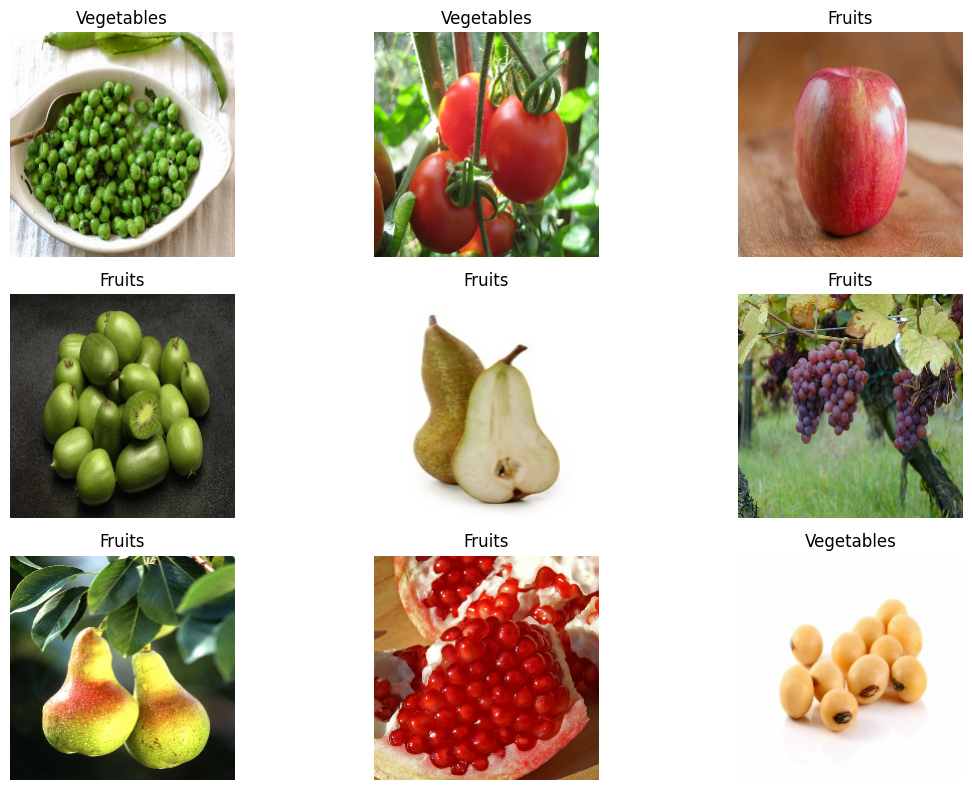

In [29]:
#Display Images From the Actual Model Dataset
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label = int(labels[i].numpy()[0])

        if label == 0:
            category = "Fruits"
        else:
            category = "Vegetables"

        plt.title(category)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
#Optimize Dataset Loading
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

In [34]:
for split in ["train", "validation", "test"]:

    fruits_path = os.path.join(binary_path, split, "Fruits")
    vegetables_path = os.path.join(binary_path, split, "Vegetables")

    print(
        split,
        len(os.listdir(fruits_path)),
        len(os.listdir(vegetables_path))
    )

train 919 2196
validation 107 244
test 109 250


In [35]:
class_names = sorted(
    os.listdir(os.path.join(binary_path, "train"))
)

print("Classes:", class_names)

Classes: ['Fruits', 'Vegetables']


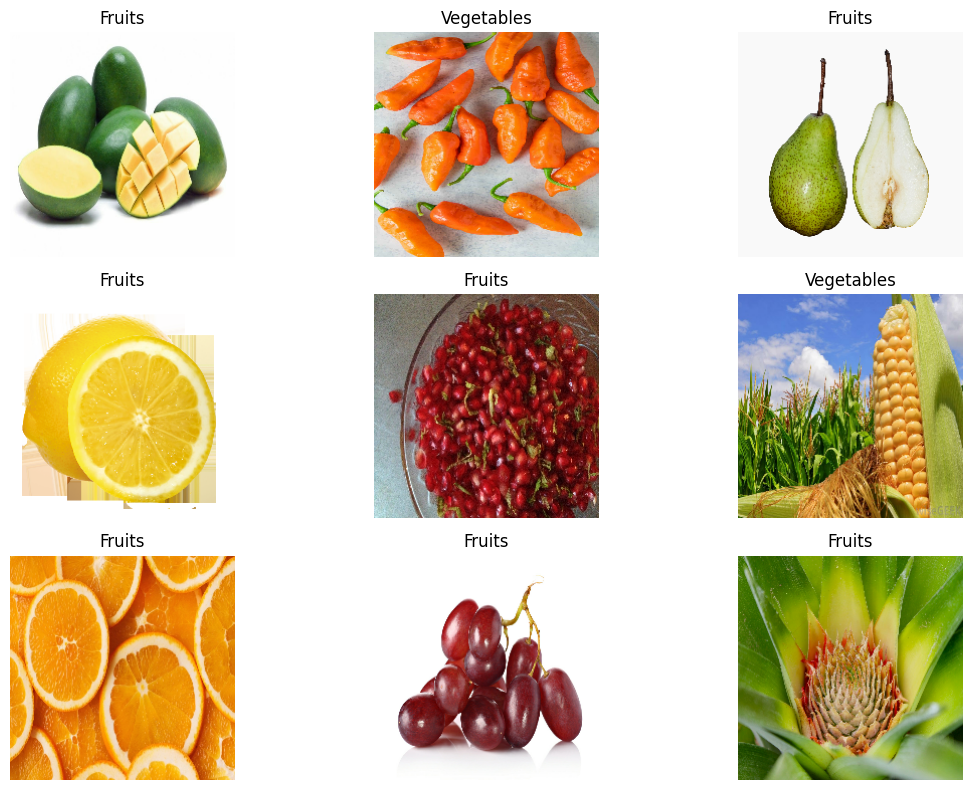

In [37]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        label = int(labels[i].numpy()[0])

        plt.title(class_names[label])

        plt.axis("off")

plt.tight_layout()
plt.show()

##  Data Augmentation

In [38]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

##  Transfer Learning Using MobileNetV2

In [39]:
#Load MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [40]:
base_model.trainable = False #Freeze MobileNetV2

##  Building the Image Classification Model

In [41]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [68]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation

])

In [43]:
model.summary() #for summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

##  Compiling the Model

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [46]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
#Calculate Class Weights

In [47]:
train_labels = []

for images, labels in train_dataset:
    train_labels.extend(
        labels.numpy().flatten()
    )

train_labels = np.array(train_labels)

classes = np.unique(train_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels
)

class_weight_dict = {
    int(classes[i]): class_weights[i]
    for i in range(len(classes))
}

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: np.float64(1.6947769314472252), 1: np.float64(0.7092440801457195)}


##  Training the Model

In [48]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.6180 - loss: 0.6524 - val_accuracy: 0.6866 - val_loss: 0.5762
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.7108 - loss: 0.5657 - val_accuracy: 0.7578 - val_loss: 0.4974
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - accuracy: 0.7644 - loss: 0.5031 - val_accuracy: 0.8063 - val_loss: 0.4507
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.7965 - loss: 0.4540 - val_accuracy: 0.8405 - val_loss: 0.4122
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.8286 - loss: 0.4073 - val_accuracy: 0.8604 - val_loss: 0.3778
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 331s 3s/step - accuracy: 0.8382 - loss: 0.3962 - val_accuracy: 0.8661 - val_loss: 0.3566
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 322s 3s/step - accuracy: 0.8555 - loss: 0.3677 - val_accuracy: 0.8718 - val_loss: 0.3391
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.8629 - loss: 0.3454 - val_accuracy: 0.8718 - v

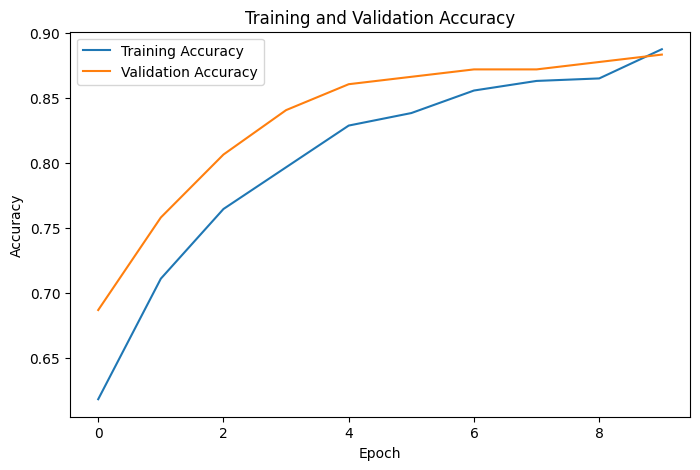

In [51]:
#Plot Training Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()

plt.show()

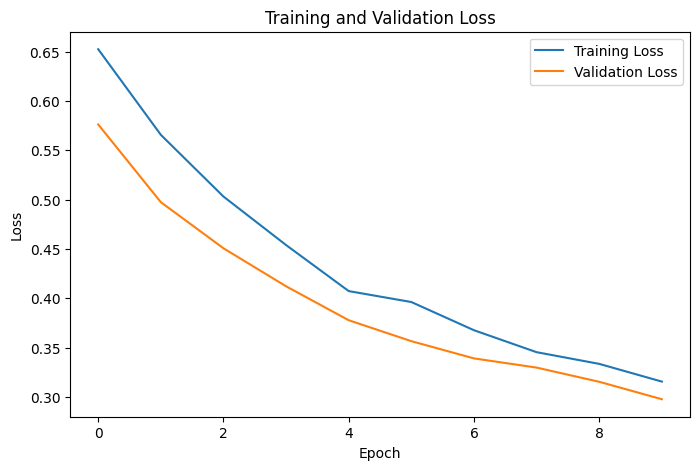

In [52]:
#Plot Training Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()

plt.show()

##  Model Evaluation

In [53]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8858 - loss: 0.2940
Test Loss: 0.2939780652523041
Test Accuracy: 0.8857938647270203


In [ ]:
#Generate Predictions

In [54]:
y_true = []
y_pred = []

In [55]:
for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predictions = (
        predictions >= 0.5
    ).astype(int).flatten()

    y_pred.extend(predictions)
    y_true.extend(
        labels.numpy().astype(int).flatten()
    )

In [56]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

##  Classification Report

In [58]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      Fruits       0.75      0.94      0.83       109
  Vegetables       0.97      0.86      0.91       250

    accuracy                           0.89       359
   macro avg       0.86      0.90      0.87       359
weighted avg       0.90      0.89      0.89       359



##  Confusion Matrix

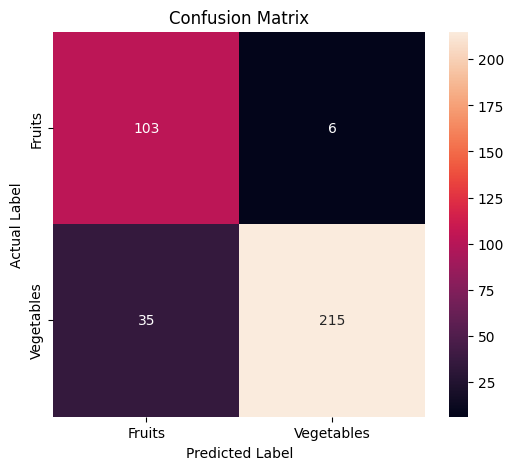

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

##  Saving the Trained Model

In [60]:
model.save(
    "/content/fruit_vegetable_classifier.keras"
)

print("Model saved successfully!")

Model saved successfully!


## 15. Prediction on a New Image

In [64]:
from google.colab import files

uploaded = files.upload()

Saving apple.jpg to apple.jpg


In [65]:
image_path = list(uploaded.keys())[0]

image = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = tf.expand_dims(
    image_array,
    axis=0
)

In [66]:
prediction = model.predict(
    image_array
)

probability = float(prediction[0][0])

if probability >= 0.5:
    predicted_class = "Vegetables"
    confidence = probability
else:
    predicted_class = "Fruits"
    confidence = 1 - probability

print("Predicted Class:", predicted_class)
print(
    "Confidence:",
    round(confidence * 100, 2),
    "%"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted Class: Fruits
Confidence: 78.03 %


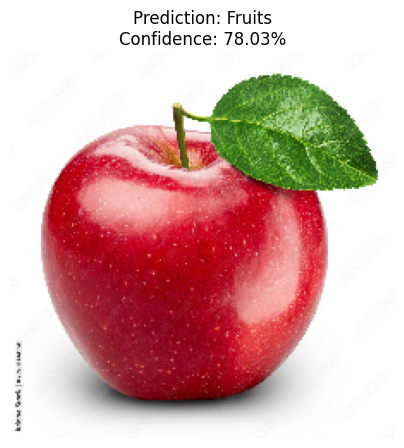

In [67]:
plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")

plt.show()